In [2]:
import torch.utils.data as data
from torch_geometric.loader import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import uproot
import numpy as np
import torch_geometric
import torch_cluster

from torch_geometric.data import Data
import torch
import awkward as ak
import numpy

import torch.nn as nn
from torch.nn import Linear, Parameter
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import add_self_loops, degree, scatter, index_to_mask
import torch.nn.functional as F

from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("device", device)

device cpu


In [1]:
def calculate_eec(part_energy, part_eta, part_phi):

    total_energy = np.sum(part_energy) + 1e-8

    EECnarrow = 0.0
    EECwide = 0.0
    e2 = 0.0
    e3 = 0.0

    z = part_energy / total_energy
    n = len(part_energy)

    for i in range(n):
        for j in range(i + 1, n):

            E1 = z[i]
            E2 = z[j]

            d_eta = part_eta[i] - part_eta[j]
            d_phi = np.arctan2(np.sin(part_phi[i] - part_phi[j]),np.cos(part_phi[i] - part_phi[j]))

            dR1 = np.sqrt(d_eta**2 + d_phi**2)

            if 0.06 < dR1 <= 0.20:
                EECnarrow += E1 * E2
            if 0.20 < dR1 <= 0.80:
                EECwide += E1 * E2

            e2 += E1 * E2 * dR1

            for k in range(j + 1, n):

                E3 = z[k]

                d_eta_ik = part_eta[i] - part_eta[k]
                d_phi_ik = np.arctan2(np.sin(part_phi[i] - part_phi[k]),np.cos(part_phi[i] - part_phi[k]))
                dR2 = np.sqrt(d_eta_ik**2 + d_phi_ik**2)

                d_eta_jk = part_eta[j] - part_eta[k]
                d_phi_jk = np.arctan2(np.sin(part_phi[j] - part_phi[k]),np.cos(part_phi[j] - part_phi[k]))
                dR3 = np.sqrt(d_eta_jk**2 + d_phi_jk**2)

                e3 += E1 * E2 * E3 * dR1 * dR2 * dR3

    return np.array([EECnarrow, EECwide, e2, e3],
                    dtype=np.float32)

In [4]:

class HyperData(Data):
    """A hypergraph sample. hyperedge_index = [node_idx ; edge_idx]; __inc__ offsets BOTH rows on batching."""
    def __inc__(self, key, value, *args, **kwargs):
        if key == "hyperedge_index":
            return torch.tensor([[self.num_nodes], [self.num_hyperedges]])
        return super().__inc__(key, value, *args, **kwargs)

class Jet_Dataset(data.Dataset):

    def __init__(self, filepath, k = 8):
        super().__init__()
        self.file = uproot.open(filepath)
        self.tree = self.file["Delphes"] #awkward high-level object
        
        needed = ["FatJet.PT","FatJet.Eta","FatJet.Mass","FatJet.Tau[5]","FatJet.SoftDroppedP4[5]","FatJet.Particles", "FatJet.Phi",
                  "Particle.PT","Particle.Eta","Particle.Phi","Particle.Px","Particle.Py","Particle.Pz","Particle.E","Particle.Mass","Particle.Charge","Particle.PID"]
        self.branch = self.tree.arrays(needed)
        self.num_entries = len(self.branch)

        self.k = k

        self.unique_pid = [-2212, -2112, -321, -211, -13, -11, 11, 13, 22, 130, 211, 321, 2112, 2212]
        self.pid_map = {pid: i for i, pid in enumerate(self.unique_pid)}
        
        #no empty ones to be passed
        self.valid_idx = []
        for i in range(self.num_entries):
            if len(self.branch["FatJet.PT"][i]) == 0:
                continue
            if len(self.branch["FatJet.SoftDroppedP4[5]"][i]) == 0:
                continue
            
            refs = self.branch["FatJet.Particles"][i, 0].refs - 1
            pt   = ak.to_numpy(self.branch["Particle.PT"][i][refs])
            if len(pt) < 2:
                continue

            self.valid_idx.append(i)

        print("Building graphs...")
        self.data_list = [self.pt_cloud(idx)for idx in self.valid_idx]
        print("Done.")


    def pt_cloud(self, idx):
        #jet, label, part, aux
        if len(self.branch["FatJet.PT"][idx]) == 0:
            raise IndexError(f"Event {idx} contains no FatJet.")
        
        #JET
        fat_pt   = np.array([self.branch["FatJet.PT"][idx][0]], dtype=np.float32)
        fat_eta  = np.array([self.branch["FatJet.Eta"][idx][0]], dtype=np.float32)
        fat_mass = np.array([self.branch["FatJet.Mass"][idx][0]], dtype=np.float32)
        #-----------Soft Drop Energy and mass--------------
        sd = self.branch["FatJet.SoftDroppedP4[5]"][idx][0][0]
        sd_energy = np.array([sd.fE], dtype=np.float32)
        
        m2 = (sd.fE**2- sd.fP.fX**2- sd.fP.fY**2- sd.fP.fZ**2)
        sd_mass = np.array([np.sqrt(max(m2, 0.0))], dtype=np.float32)
        # ---------- tau_21 ----------
        tau = self.branch["FatJet.Tau[5]"][idx][0]
        tau1 = np.array([tau[0]], dtype=np.float32)
        tau2 = np.array([tau[1]], dtype=np.float32)
        tau21 = np.full_like(tau1, -1.0)
        np.divide(tau2, tau1, out=tau21, where=tau1 > 0)

        tau21_undefined = (tau1 <= 0).astype(np.float32)

        jet_feat = np.stack([fat_pt,fat_eta,fat_mass,sd_energy,tau21,tau21_undefined],axis=1)
        
        #part
        refs = self.branch["FatJet.Particles"][idx, 0].refs - 1

        #Particle level features
        part_pt     = ak.to_numpy(self.branch["Particle.PT"][idx][refs])
        part_eta    = ak.to_numpy(self.branch["Particle.Eta"][idx][refs])
        part_phi    = ak.to_numpy(self.branch["Particle.Phi"][idx][refs])
        part_px     = ak.to_numpy(self.branch["Particle.Px"][idx][refs])
        part_py     = ak.to_numpy(self.branch["Particle.Py"][idx][refs])
        part_pz     = ak.to_numpy(self.branch["Particle.Pz"][idx][refs])
        part_energy = ak.to_numpy(self.branch["Particle.E"][idx][refs])
        part_mass   = ak.to_numpy(self.branch["Particle.Mass"][idx][refs])
        part_charge = ak.to_numpy(self.branch["Particle.Charge"][idx][refs])
        part_pid    = ak.to_numpy(self.branch["Particle.PID"][idx][refs])    
        part_pid    = torch.tensor([self.pid_map[p] for p in part_pid],dtype=torch.long)

        #making suitable features
        pt_frac = part_pt / (fat_pt.item() + 1e-8)
        part_energy = np.log(part_energy + 1e-8)

        coords = torch.tensor(np.stack([part_eta, part_phi], axis=1),dtype=torch.float32)
        #Normalization
        part_eta = (part_eta - part_eta.mean()) / (part_eta.std() + 1e-8)
        part_phi = (part_phi - part_phi.mean()) / (part_phi.std() + 1e-8)
        part_energy = (part_energy - part_energy.mean()) / (part_energy.std() + 1e-8)
        part_px = (part_px - part_px.mean()) / (part_px.std() + 1e-8)
        part_py = (part_py - part_py.mean()) / (part_py.std() + 1e-8)
        part_pz = (part_pz - part_pz.mean()) / (part_pz.std() + 1e-8)
        part_feat = torch.tensor(np.stack([pt_frac,part_eta,part_energy,part_px, part_py, part_pz,part_charge, part_mass],axis=1),dtype=torch.float32)
        
        n_particles = len(part_pt)
        part_feat[torch.isnan(part_feat)] = 0.0

        #Hyperedges
        R = 0.2
        node_idx = []
        edge_idx = []
        for centre in range(n_particles):
            d_eta = coords[:, 0] - coords[centre, 0]
            d_phi = coords[:, 1] - coords[centre, 1]
            d_phi = torch.atan2(torch.sin(d_phi), torch.cos(d_phi))  # wrap to (-pi, pi]
            dr = torch.sqrt(d_eta**2 + d_phi**2)
            members = torch.where(dr < R)[0]
            
            node_idx.extend(members.tolist())
            edge_idx.extend([centre]*len(members))

        #EEC Observables
        eec = calculate_eec(part_energy, part_eta, part_phi)

        #Data
        data   = HyperData(x=part_feat,hyperedge_index = torch.tensor([node_idx, edge_idx],dtype=torch.long))        
        data.y = torch.tensor(sd_mass, dtype=torch.float32)
        data.num_hyperedges = torch.tensor(n_particles, dtype=torch.long)
        data.pid = part_pid
        data.jet = torch.from_numpy(jet_feat).float()
        data.eec = torch.tensor(eec)
                    
        return data

    def __len__(self):
        return len(self.valid_idx)
    
    def __getitem__(self, idx):
        return self.data_list[idx]


f_h = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/dihiggs_output_13TeV.root"
f_qcd = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/qcd_output_13TeV.root"

jet_dataset_h = Jet_Dataset(f_h)
jet_dataset_qcd = Jet_Dataset(f_qcd)


Building graphs...
Done.
Building graphs...
Done.


In [5]:
print(len(jet_dataset_h))

10000


In [6]:
from torch.utils.data import ConcatDataset
dataset = ConcatDataset([jet_dataset_h, jet_dataset_qcd])

#Creating training and testing datasets
batch_size = 32
test_size = 0.15
indices = list(range(len(dataset)))
np.random.shuffle(indices)
split = int(np.floor(test_size * len(dataset)))
test_index, valid_index, train_index,   = indices[:split], indices[split:split*2], indices[split*2:]

all_jet = []
all_eec = []
mass = []
for idx in train_index:
    all_jet.append(dataset[idx].jet)
    all_eec.append(dataset[idx].eec)
    mass.append(dataset[idx].y)

all_jet = torch.cat(all_jet, dim=0)
jet_mean = all_jet.mean(dim=0)
jet_std = all_jet.std(dim=0) + 1e-8

mass = torch.cat(mass, dim=0)
mass_mean = mass.mean(dim=0)
mass_std = mass.std(dim=0) + 1e-8

all_eec = torch.stack(all_eec, dim=0)
eec_mean = all_eec.mean(dim=0)
eec_std = all_eec.std(dim=0) + 1e-8

for i in range(len(dataset)):
    dataset[i].jet = (dataset[i].jet - jet_mean) / jet_std
    dataset[i].y = (dataset[i].y - mass_mean) / mass_std
    dataset[i].eec = (dataset[i].eec - eec_mean) /eec_std    

# define samplers for obtaining training and testing batches
train_sampler = SubsetRandomSampler(train_index)
test_sampler = SubsetRandomSampler(test_index)
valid_sampler = SubsetRandomSampler(valid_index)
train_load = DataLoader(dataset, batch_size = batch_size, sampler = train_sampler)
test_load = DataLoader(dataset, batch_size = batch_size, sampler = test_sampler)
valid_loader = DataLoader(dataset, batch_size = batch_size, sampler = valid_sampler)


In [7]:
def mlp(i, o, h=64):
    return nn.Sequential(nn.Linear(i, h),nn.BatchNorm1d(h), nn.SiLU(),nn.Dropout(0.2), 
                         nn.Linear(h, h),nn.BatchNorm1d(h), nn.SiLU(), nn.Dropout(0.2), 
                         nn.Linear(h, o))

class DeepSetsAgg(nn.Module):
    """The Module-1 atom:  rho( sum_over_group phi(x) ).  Used twice to make one AllSet layer."""
    def __init__(self, in_dim, out_dim, reduce="mean"):
        super().__init__()
        self.phi = mlp(in_dim, out_dim)
        self.rho = mlp(out_dim, out_dim)
        self.reduce = reduce
    def forward(self, x, src, index, dim_size):
        # gather phi(x) for each membership (src), pool by `index` (the group id), decode with rho
        agg = scatter(self.phi(x)[src], index, dim=0, dim_size=dim_size, reduce=self.reduce)
        return self.rho(agg)

class AllSetLayer(nn.Module):
    """One hypergraph message-passing layer = TWO nested Deep Sets (V->E then E->V)."""
    def __init__(self, dim):
        super().__init__()
        self.v2e = DeepSetsAgg(dim, dim)        # nodes  -> hyperedges
        self.e2v = DeepSetsAgg(dim, dim)        # hyperedges -> nodes
        self.norm = nn.LayerNorm(dim)
    def forward(self, h, node_idx, edge_idx, num_nodes, num_edges):
        z = self.v2e(h, node_idx, edge_idx, num_edges)        # each hyperedge aggregates its member nodes
        h = self.norm(h + self.e2v(z, edge_idx, node_idx, num_nodes))   # each node aggregates its hyperedges
        return h, z

from torch_geometric.nn import AttentionalAggregation

class HypergraphNet(nn.Module):
    
    def __init__(self, in_feat, n_classes, dim=64, n_layers=4):
        super().__init__()
        self.pid_embedding = nn.Embedding(14, 8)
        self.embed = mlp(in_feat + 8, dim)
        self.layers = nn.ModuleList([AllSetLayer(dim) for _ in range(n_layers)])
        self.head = nn.Sequential(nn.LayerNorm(dim + 6 + 4),nn.Linear(dim + 6 + 4, dim),nn.SiLU(),nn.Dropout(0.2),
                                    nn.Linear(dim, dim),nn.SiLU(),nn.Dropout(0.2),nn.Linear(dim, n_classes),)
        self.pool = AttentionalAggregation( gate_nn=nn.Sequential(nn.Linear(dim, dim),nn.SiLU(),nn.Linear(dim, 1)))

    def forward(self, data):
        #PID 
        x = data.x; pid = data.pid; jet_feat = data.jet
        pid_feat = self.pid_embedding(pid)
        x = torch.cat([x, pid_feat], dim = 1)
        
        h = self.embed(x); batch = data.batch; N = h.size(0)
        node_idx, edge_idx = data.hyperedge_index
        num_edges = int(edge_idx.max()) + 1
        
        for layer in self.layers:
            h, _ = layer(h, node_idx, edge_idx, N, num_edges)

        #Jet level features
        h = self.pool(h, batch)
        num_graphs = batch.max().item() + 1
        jet_eec = data.eec.view(num_graphs, 4)
        h = torch.cat([h, jet_feat], dim=1)
        h = torch.cat([h, jet_eec], dim=1)
        return self.head(h)

hyper_model = HypergraphNet(in_feat=len(dataset[0].x[0]), n_classes=1).to(device)
print("forward (hyper):   ", tuple(hyper_model(next(iter(train_load)).to(device)).shape))

forward (hyper):    (32, 1)


In [8]:
dataset[9]

HyperData(x=[28, 8], hyperedge_index=[2, 422], y=[1], num_hyperedges=28, pid=[28], jet=[1, 6], eec=[4])

In [9]:
epochs = 25
optimizer = torch.optim.AdamW(hyper_model.parameters(), lr = 1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss = nn.MSELoss()

In [10]:
from tqdm import tqdm
from tqdm import trange

In [11]:
data = next(iter(train_load))
print(hyper_model(data).squeeze().shape)
print(data.y.shape)

torch.Size([32])
torch.Size([32])


Processing:   4%|▍         | 1/25 [01:08<27:26, 68.60s/it]

Epoch 0 | Train Loss: 0.2273671926939052 | Test Loss: 0.16645135143969922


Processing:   8%|▊         | 2/25 [02:13<25:25, 66.34s/it]

Epoch 1 | Train Loss: 0.15428588320352307 | Test Loss: 0.1334474984794221


Processing:  12%|█▏        | 3/25 [03:06<22:02, 60.09s/it]

...

Epoch 22 | Train Loss: 0.09002185100902162 | Test Loss: 0.08616711853190939


Processing:  96%|█████████▌| 24/25 [25:13<00:56, 56.12s/it]

Epoch 23 | Train Loss: 0.08751541909817011 | Test Loss: 0.08560817482623648


Processing: 100%|██████████| 25/25 [26:19<00:00, 63.20s/it]

Epoch 24 | Train Loss: 0.08454284974327099 | Test Loss: 0.08602623401724911
Best for test Loss: 0.08560817482623648


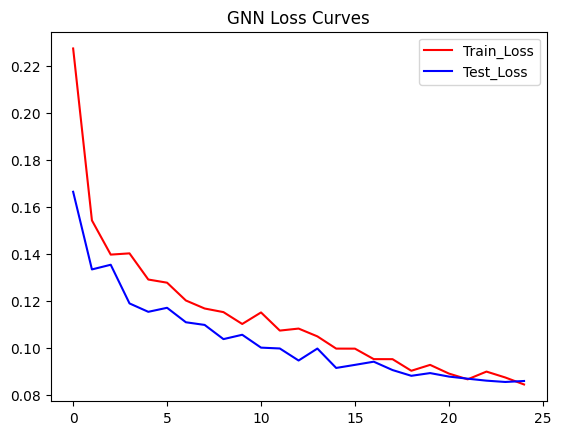

In [12]:
#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0

    for data in train_loader:
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data).squeeze()
        #print(y_pred.dtype, label.dtype)
        
        loss = loss_fn(y_pred, data.y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    train_loss /= len(train_loader)
    return train_loss

def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:
            data = data.to(device)
            test_pred = model(data).squeeze()
            
            #print("TEST_PRED:",test_pred)
            loss = loss_fn(test_pred, data.y)
            #print("Data_label:", data.label )
            test_loss += loss.item()
           
    test_loss /= len(test_loader)

    return test_loss

ep = []
result1 = []
result2 = []
best_loss = torch.inf

counter = 0
patience = 10
epochs = 25

for epoch in trange (epochs, desc="Processing"):
    train_loss = train(train_load, hyper_model, optimizer, loss)
    test_loss = test( test_load,hyper_model, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save({
                "model": hyper_model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
            }, "checkpoint.pt")
    else:
        counter += 1
    
    if counter==patience:
        print("Stopping")
        break
    
    scheduler.step()
   

print(f"Best for test Loss: {best_loss}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("GNN Loss Curves")
plt.show()


In [13]:


def eval_model(model,valid_loader ):
    model.eval()

    all_preds = []; all_truth = []

    with torch.inference_mode():
        for data in valid_loader:
            data = data.to(device)
            Valid_pred = model(data).squeeze()
                        
            pred_mass = Valid_pred * mass_std + mass_mean
            truth_mass = data.y * mass_std + mass_mean

            all_preds.append(pred_mass.cpu())
            all_truth.append(truth_mass.cpu())

            print("PREDICTED SD_MASS: ", pred_mass[-1])
            print("TRUTH SD_MASS: ", truth_mass[-1])


        all_preds = torch.cat(all_preds)
        all_truth = torch.cat(all_truth)

        mae = torch.mean(torch.abs(all_preds - all_truth))
        mse = torch.mean((all_preds - all_truth) ** 2)
        rmse = torch.sqrt(mse)

        print(f"\nMAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")

    return all_preds, all_truth

model_test = HypergraphNet(in_feat=len(dataset[0].x[0]), n_classes=1)
checkpoint = torch.load("checkpoint.pt", map_location=device)
model_test.load_state_dict(checkpoint["model"])


pred_mass, true_mass = eval_model(model_test,valid_loader)


PREDICTED SD_MASS:  tensor(14.2187)
TRUTH SD_MASS:  tensor(78.4558)
PREDICTED SD_MASS:  tensor(130.3306)
TRUTH SD_MASS:  tensor(119.8462)
PREDICTED SD_MASS:  tensor(39.3836)
TRUTH SD_MASS:  tensor(44.2214)
PREDICTED SD_MASS:  tensor(115.2906)
TRUTH SD_MASS:  tensor(110.5312)
PREDICTED SD_MASS:  tensor(12.1946)
TRUTH SD_MASS:  tensor(13.9533)
PREDICTED SD_MASS:  tensor(14.7158)
TRUTH SD_MASS:  tensor(5.8869)
PREDICTED SD_MASS:  tensor(241.2409)
TRUTH SD_MASS:  tensor(273.9417)
PREDICTED SD_MASS:  tensor(81.3995)
TRUTH SD_MASS:  tensor(100.9525)
PREDICTED SD_MASS:  tensor(108.8297)
TRUTH SD_MASS:  tensor(125.0787)
PREDICTED SD_MASS:  tensor(5.3947)
TRUTH SD_MASS:  tensor(3.5752)
PREDICTED SD_MASS:  tensor(24.0434)
TRUTH SD_MASS:  tensor(24.0416)
PREDICTED SD_MASS:  tensor(43.7272)
TRUTH SD_MASS:  tensor(19.4040)
PREDICTED SD_MASS:  tensor(44.1552)
TRUTH SD_MASS:  tensor(33.2965)
PREDICTED SD_MASS:  tensor(110.4573)
TRUTH SD_MASS:  tensor(112.0363)
PREDICTED SD_MASS:  tensor(17.9780)
TRUT

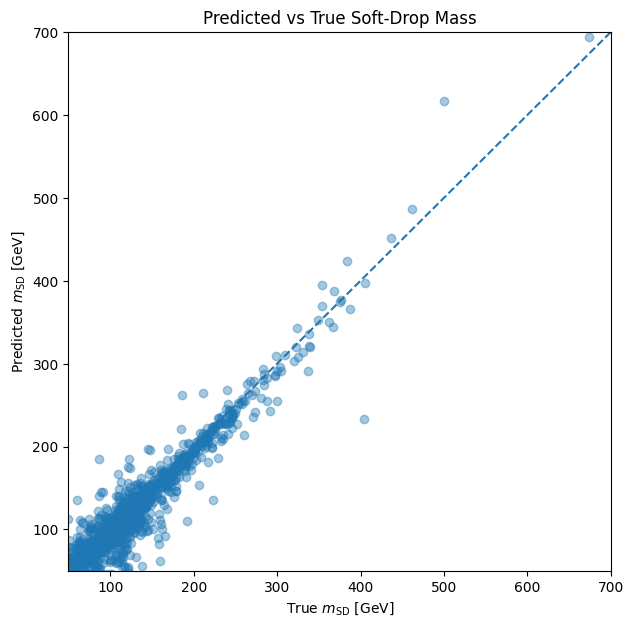

In [14]:
plt.figure(figsize=(7,7))

plt.scatter(true_mass.numpy(),pred_mass.numpy(),alpha=0.4)
lims = [min(true_mass.min(), pred_mass.min()),max(true_mass.max(), pred_mass.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlim(50,700)
plt.ylim(50,700)
plt.xlabel(r"True $m_{\mathrm{SD}}$ [GeV]")
plt.ylabel(r"Predicted $m_{\mathrm{SD}}$ [GeV]")
plt.title("Predicted vs True Soft-Drop Mass")

plt.show()

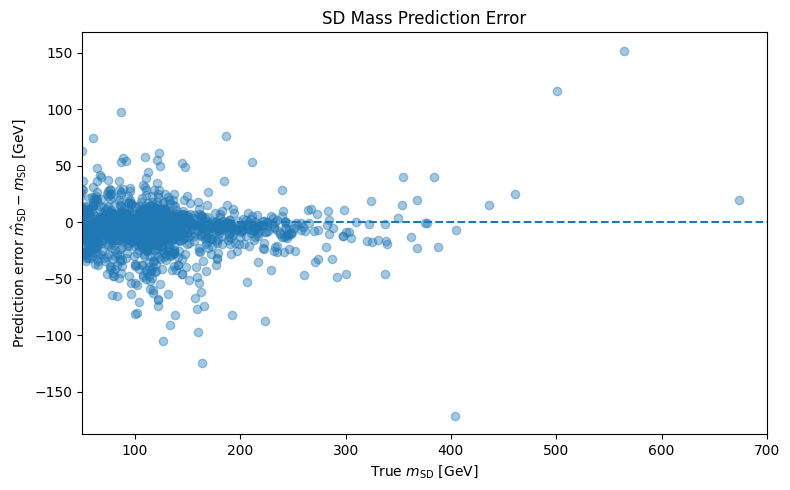

In [15]:
pred = pred_mass.detach().cpu().numpy().flatten()
true = true_mass.detach().cpu().numpy().flatten()

error = pred - true

plt.figure(figsize=(8, 5))

plt.scatter(true, error, alpha=0.4)

# Zero-error line
plt.axhline(0, linestyle="--")

plt.xlabel(r"True $m_{\mathrm{SD}}$ [GeV]")
plt.ylabel(r"Prediction error $\hat{m}_{\mathrm{SD}}-m_{\mathrm{SD}}$ [GeV]")
plt.title(r"SD Mass Prediction Error")
plt.xlim(50,700)
plt.tight_layout()
plt.show()

In [16]:
print(f"Mean error (bias): {error.mean():.2f} GeV")
print(f"Std of error: {error.std():.2f} GeV")
print(f"RMSE: {np.sqrt((error**2).mean()):.2f} GeV")
print(f"Median absolute error: {np.median(np.abs(error)):.2f} GeV")

Mean error (bias): -0.02 GeV
Std of error: 18.73 GeV
RMSE: 18.73 GeV
Median absolute error: 6.47 GeV
